# Norepinephrine–dopamine sequential integration in astroglia drives behavioral state transitions 

Sijia Wang<sup>1,2†</sup>, Shilin Fang<sup>1†</sup>, Thiago O. Bezerra<sup>3†</sup>, Zhiyuan Wang<sup>1,2</sup>, Qimeng Zhao<sup>1,2</sup>, Xiaoou Wang<sup>1,2</sup>, Liang Wang<sup>4</sup>, Kui Wang<sup>1</sup>, Lijun Chen<sup>1,2</sup>, Funing Li<sup>1</sup>, Yuchen Gong<sup>1,2</sup>, Yongxin Yang<sup>1,2</sup>, Jiesi Feng<sup>5</sup>, Yu Zheng<sup>5</sup>, Yulong Li<sup>5</sup>, Jun Chu<sup>4</sup>, Gerald M. Pao<sup>6</sup>, Xufei Du<sup>1,2</sup>, Jiu-lin Du<sup>1,2</sup>, Antonio C. Roque<sup>3</sup>, Yu Mu<sup>1,2*</sup>

Affiliations:

<sup>1</sup> Institute of Neuroscience, State Key Laboratory of Brain Cognition and Brain-inspired Intelligence Technology, Center for Excellence in Brain Science and Intelligence Technology, Chinese Academy of Sciences, 320 Yue-Yang Road, Shanghai 200031, China.

<sup>2</sup> University of Chinese Academy of Sciences,19A Yu-Quan Road, Beijing 100049, China.

<sup>3</sup> Department of Physics, School of Philosophy, Sciences and Letters of Ribeirão Preto, University of São Paulo, Ribeirão Preto, São Paulo, Brazil.

<sup>4</sup> Research Center for Primate Neuromodulation and Neuroimaging, Shenzhen Institutes of Advanced Technology, Chinese Academy of Sciences, Shenzhen 518055, China.

<sup>5</sup> Academy for Advanced Interdisciplinary Studies, School of Psychological and Cognitive Sciences, Peking University, Beijing 100871, China.

<sup>6</sup> Okinawa Institute of Science and Technology Graduate University, Biological Nonlinear Dynamics Data Science Unit, Okinawa 904-0495, Japan.

<sup>†</sup> These authors contributed equally to this work.

<sup>*</sup> Corresponding author. Email: my@ion.ac.cn

## Analysis of astrocytic cAMP signaling dynamics

This notebook provides the computational pipeline for analyzing and visualizing simulation data from the astrocytic cAMP model. The example output demonstrates the cellular response to concurrent noradrenergic (NE) and dopaminergic (DA) stimulation, with onset at $t = 20$ s. Resulting traces include temporal dynamics for $\mathrm{Ca^{2+}}$, $\mathrm{IP_3}$, DA, NE, and cAMP.

## Requirements

Python 3.12.7 \
Numpy 1.26.4 \
Matplotlib 3.9.2

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ImportTextFile(directory_file: str = '', input_file: str = '') -> list:

    out_result = []

    with open(os.path.join(directory_file, input_file)) as file:
        for line in file: out_result.append(line)
    
    return out_result

def ConvertTextToArray(text_result: list = '') -> np.ndarray:

    n_comparts = len(text_result[0].split(';')) - 1
    n_points = len(text_result)

    out_result = np.zeros(shape = (n_comparts, n_points))

    for i_line, line in enumerate(text_result):

        splitted_line = line.replace('\n', '').split(';')
        for i_row, row in enumerate(splitted_line):
            
            if i_row == 0: continue
                
            out_result[i_row - 1, i_line] = float(row)
            
    return out_result

# Tests

In [20]:
folder = 'Output' 

Ca = ConvertTextToArray(ImportTextFile(folder, f'CaiNADA_Example.txt'))[0]
IP3 = ConvertTextToArray(ImportTextFile(folder, f'IP3NADA_Example.txt'))[0]
cAMP = ConvertTextToArray(ImportTextFile(folder, f'cAMPNADA_Example.txt'))[0]
DA = ConvertTextToArray(ImportTextFile(folder, f'DANADA_Example.txt'))[0]
NE = ConvertTextToArray(ImportTextFile(folder, f'NENADA_Example.txt'))[0]

Text(0.5, 0, 't (s)')

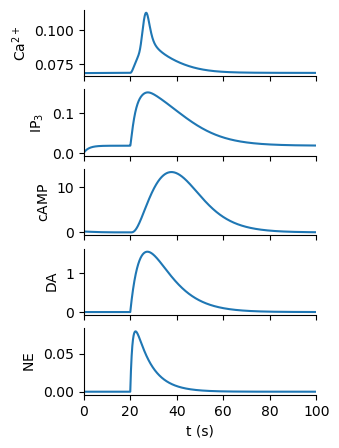

In [33]:
fig, ax = plt.subplots(5, 1, sharex = True, figsize=(3, 5))

t = np.linspace(0, 100, Ca.shape[0])

# Ca2+
ax[0].plot(t, Ca*1000)
ax[0].set_ylabel(r'$\mathrm{Ca^{2+}}$')

# IP3
ax[1].plot(t, IP3*1000)
ax[1].set_ylabel(r'$\mathrm{IP_3}$')

# cAMP
ax[2].plot(t, cAMP)
ax[2].set_ylabel(r'$\mathrm{cAMP}$')

# DA
ax[3].plot(t, DA)
ax[3].set_ylabel(r'$\mathrm{DA}$')

# NE
ax[4].plot(t, NE)
ax[4].set_ylabel(r'$\mathrm{NE}$')


for axis in ax:
    for spine in ('right', 'top'): axis.spines[spine].set_visible(False)
    axis.set_xlim(0, 100)

ax[-1].set_xlabel('t (s)')
